
# YuvaIntern Week 2 - Exploratory Data Analysis & Visualization



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. DATA ACQUISITION

In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

bank_zip = "bank.zip"

# Download the public dataset
import urllib.request

urllib.request.urlretrieve(url, bank_zip)

print("Bank Marketing dataset downloaded successfully.")

Bank Marketing dataset downloaded successfully.


In [7]:
import zipfile
import os

# Extract the downloaded ZIP file
with zipfile.ZipFile(bank_zip, "r") as zip_ref:
    zip_ref.extractall("bank_data")

print("Dataset extracted successfully.")

# Check extracted files
print(os.listdir("bank_data"))

Dataset extracted successfully.
['bank.csv', 'bank-full.csv', 'bank-names.txt']


In [8]:
data_path = "bank_data/bank-full.csv"

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 45211
Columns: 17


In [9]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [11]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(45211, 17)


In [12]:
df.to_csv("bank_marketing_acquired.csv", index=False)

print("Acquired dataset saved as bank_marketing_acquired.csv")

Acquired dataset saved as bank_marketing_acquired.csv


# 2. DATASET OVERVIEW AND INITIAL ANALYSIS

In [13]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Number of rows and columns
print("\nDataset dimensions:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Column names
print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# Data types
print("\nData types:")
print(df.dtypes)

# First 10 rows
print("\nFirst 10 records:")
display(df.head(10))

# Random sample
print("\nRandom sample of 5 records:")
display(df.sample(5, random_state=42))

DATASET OVERVIEW

Dataset dimensions:
Rows: 45211
Columns: 17

Column names:
1. age
2. job
3. marital
4. education
5. default
6. balance
7. housing
8. loan
9. contact
10. day
11. month
12. duration
13. campaign
14. pdays
15. previous
16. poutcome
17. y

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

First 10 records:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no



Random sample of 5 records:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no


In [14]:
# DESCRIPTIVE STATISTICS

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# Numerical variables
print("\nNumerical summary:")
display(df.describe())

# Categorical variables
print("\nCategorical summary:")
display(df.describe(include="object").T)

DESCRIPTIVE STATISTICS

Numerical summary:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000



Categorical summary:


,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


In [15]:
# UNIQUE VALUES IN CATEGORICAL FEATURES

categorical_columns = df.select_dtypes(include="object").columns

print("=" * 60)
print("UNIQUE VALUES")
print("=" * 60)

for column in categorical_columns:
    print(f"\n{column}:")
    print("Number of unique values:", df[column].nunique())
    print(df[column].unique())

UNIQUE VALUES

job:
Number of unique values: 12
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital:
Number of unique values: 3
['married' 'single' 'divorced']

education:
Number of unique values: 4
['tertiary' 'secondary' 'unknown' 'primary']

default:
Number of unique values: 2
['no' 'yes']

housing:
Number of unique values: 2
['yes' 'no']

loan:
Number of unique values: 2
['no' 'yes']

contact:
Number of unique values: 3
['unknown' 'cellular' 'telephone']

month:
Number of unique values: 12
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome:
Number of unique values: 4
['unknown' 'failure' 'other' 'success']

y:
Number of unique values: 2
['no' 'yes']


In [16]:
# TARGET VARIABLE ANALYSIS

print("=" * 60)
print("TARGET VARIABLE: SUBSCRIPTION")
print("=" * 60)

print("\nSubscription counts:")
display(df["y"].value_counts())

print("\nSubscription percentages:")
display(
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TARGET VARIABLE: SUBSCRIPTION

Subscription counts:


,count
y,
no,39922
yes,5289



Subscription percentages:


,proportion
y,
no,88.3
yes,11.7


# 3. DATA QUALITY ANALYSIS

In [17]:
print("=" * 60)
print("DATA QUALITY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 3.1 Missing Values
# ------------------------------------------------------------

print("\n1. Missing values by column:")
missing_values = df.isnull().sum()
print(missing_values)

print("\nTotal missing values:")
print(missing_values.sum())


# ------------------------------------------------------------
# 3.2 Duplicate Records
# ------------------------------------------------------------

print("\n2. Duplicate records:")
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


# ------------------------------------------------------------
# 3.3 Unknown / Special Values
# ------------------------------------------------------------

print("\n3. Special / unknown values:")

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    unknown_count = (df[column] == "unknown").sum()

    if unknown_count > 0:
        percentage = (unknown_count / len(df)) * 100

        print(
            f"{column}: {unknown_count} unknown values "
            f"({percentage:.2f}%)"
        )


# ------------------------------------------------------------
# 3.4 Special Values in pdays and previous
# ------------------------------------------------------------

print("\n4. Special values in pdays:")
print("Number of -1 values:", (df["pdays"] == -1).sum())
print(
    "Percentage:",
    round((df["pdays"] == -1).mean() * 100, 2),
    "%"
)

print("\n5. Special values in previous:")
print("Number of 0 values:", (df["previous"] == 0).sum())
print(
    "Percentage:",
    round((df["previous"] == 0).mean() * 100, 2),
    "%"
)


# ------------------------------------------------------------
# 3.5 Numerical Range Check
# ------------------------------------------------------------

print("\n6. Numerical range check:")

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print(
        f"{column}: "
        f"min={df[column].min()}, "
        f"max={df[column].max()}"
    )

DATA QUALITY ANALYSIS

1. Missing values by column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing values:
0

2. Duplicate records:
Number of duplicate rows: 0

3. Special / unknown values:
job: 288 unknown values (0.64%)
education: 1857 unknown values (4.11%)
contact: 13020 unknown values (28.80%)
poutcome: 36959 unknown values (81.75%)

4. Special values in pdays:
Number of -1 values: 36954
Percentage: 81.74 %

5. Special values in previous:
Number of 0 values: 36954
Percentage: 81.74 %

6. Numerical range check:
age: min=18, max=95
balance: min=-8019, max=102127
day: min=1, max=31
duration: min=0, max=4918
campaign: min=1, max=63
pdays: min=-1, max=871
previous: min=0, max=275


# 4. UNIVARIATE EXPLORATORY DATA ANALYSIS

UNIVARIATE EXPLORATORY DATA ANALYSIS


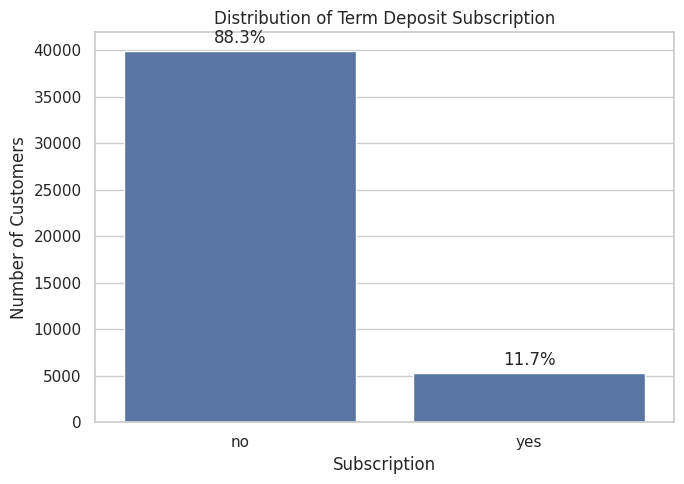

In [19]:
print("=" * 60)
print("UNIVARIATE EXPLORATORY DATA ANALYSIS")
print("=" * 60)

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 4.1 Target Variable Distribution
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="y"
)

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

# Add percentages above bars
total = len(df)

for container in ax.containers:
    labels = [
        f"{(value / total) * 100:.1f}%"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

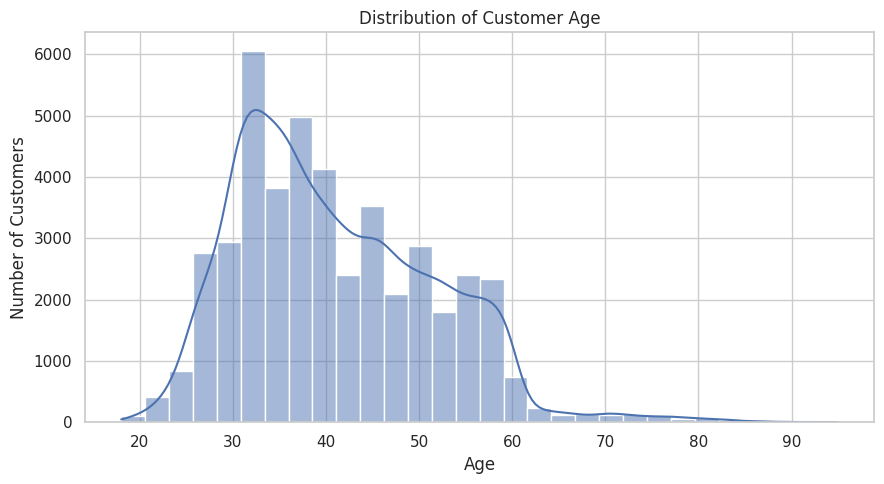

In [20]:
# 4.2 Age Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

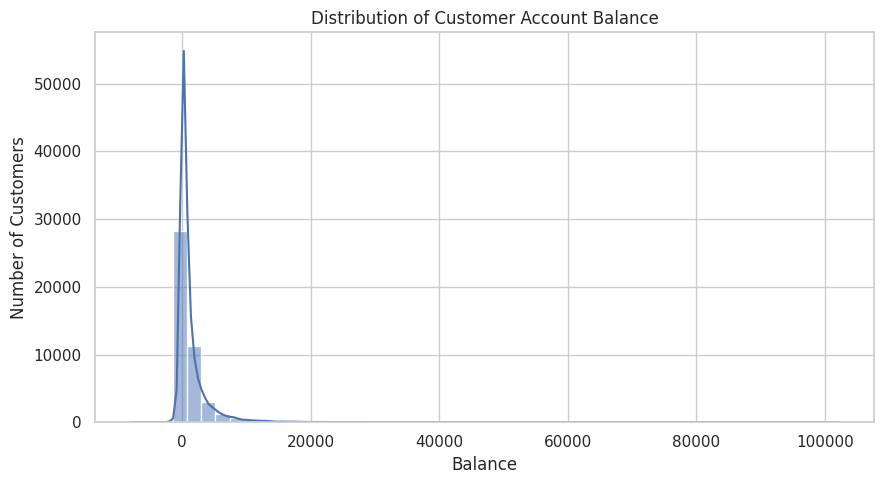

In [21]:
# 4.3 Balance Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="balance",
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Account Balance")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

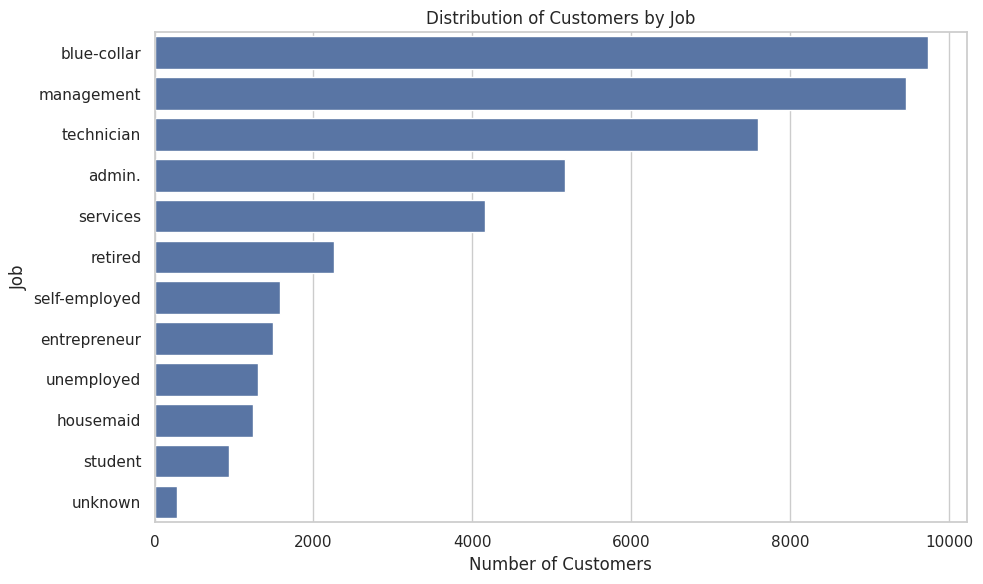

In [22]:
# 4.4 Job Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

job_order = df["job"].value_counts().index

sns.countplot(
    data=df,
    y="job",
    order=job_order
)

plt.title("Distribution of Customers by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.tight_layout()
plt.show()

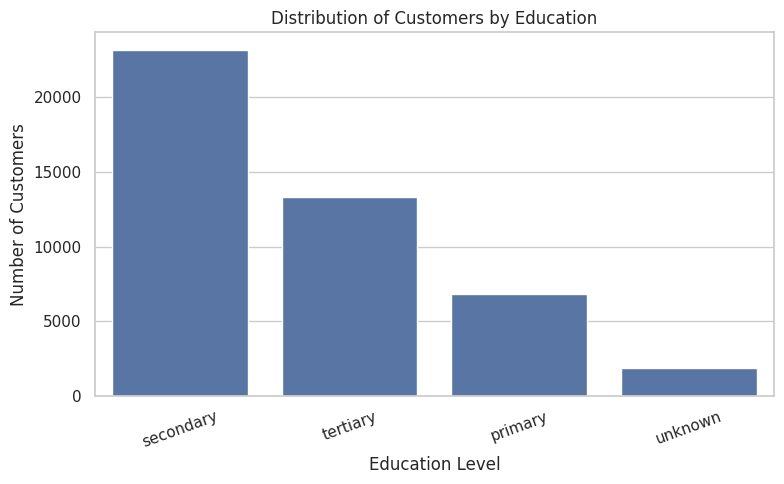

In [23]:
# 4.5 Education Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

education_order = df["education"].value_counts().index

sns.countplot(
    data=df,
    x="education",
    order=education_order
)

plt.title("Distribution of Customers by Education")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

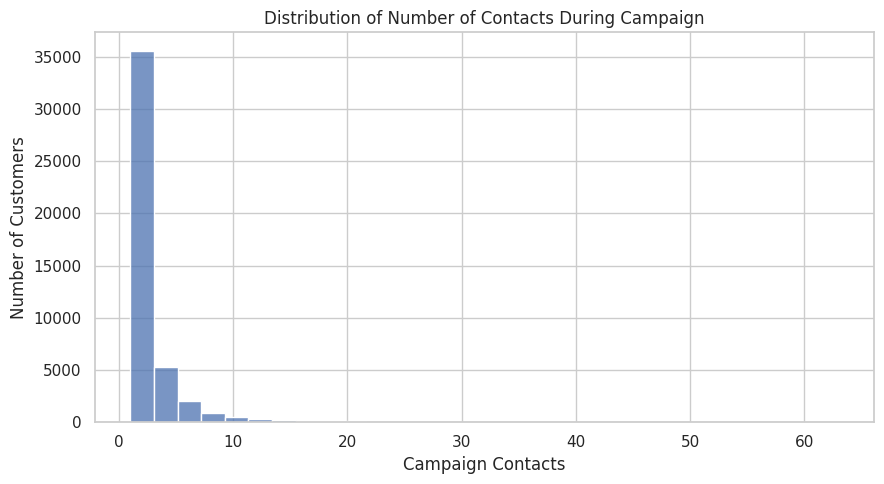

In [24]:
# 4.6 Campaign Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="campaign",
    bins=30
)

plt.title("Distribution of Number of Contacts During Campaign")
plt.xlabel("Campaign Contacts")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 5. BIVARIATE EXPLORATORY DATA ANALYSIS

# Relationship Between Features and Subscription

BIVARIATE EXPLORATORY DATA ANALYSIS

Subscription rate by job:


y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


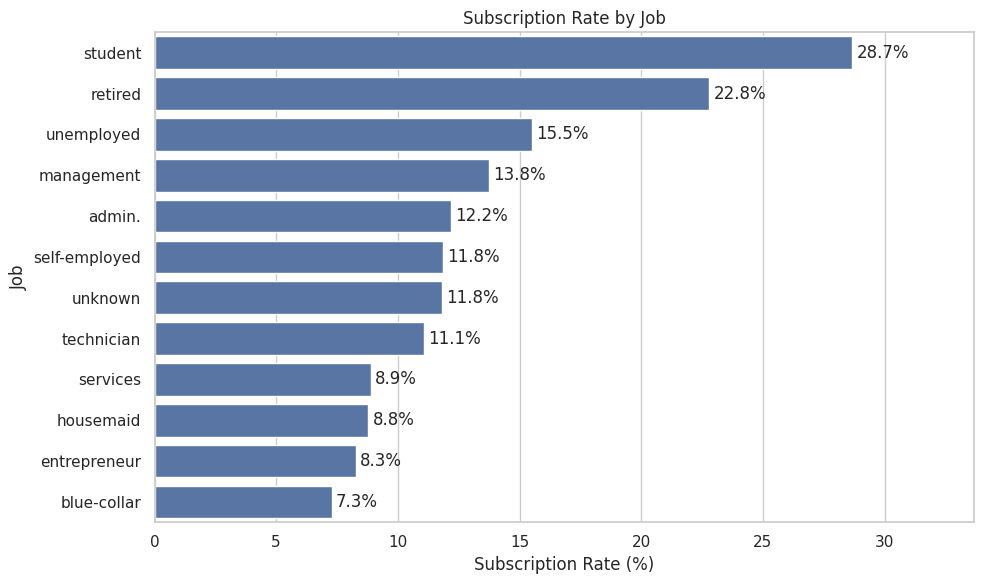

In [25]:
print("=" * 60)
print("BIVARIATE EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 5.1 Subscription Rate by Job
# ------------------------------------------------------------

job_subscription = (
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    ) * 100
)

job_subscription = job_subscription.sort_values(
    by="yes",
    ascending=False
)

print("\nSubscription rate by job:")
display(job_subscription)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=job_subscription.reset_index(),
    x="yes",
    y="job"
)

plt.title("Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.xlim(0, job_subscription["yes"].max() + 5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


Subscription rate by education:


y,no,yes
education,,
tertiary,84.993610,15.006390
unknown,86.429725,13.570275
secondary,89.440565,10.559435
primary,91.373522,8.626478


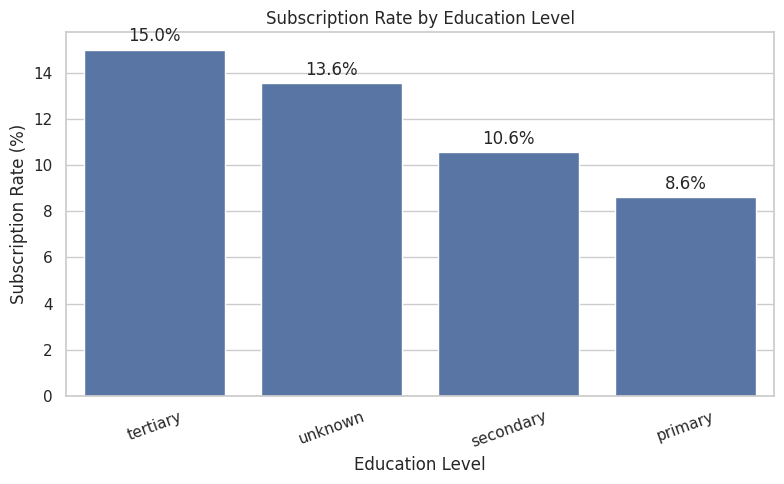

In [26]:
# 5.2 Subscription Rate by Education
# ------------------------------------------------------------

education_subscription = (
    pd.crosstab(
        df["education"],
        df["y"],
        normalize="index"
    ) * 100
)

education_subscription = education_subscription.sort_values(
    by="yes",
    ascending=False
)

print("\nSubscription rate by education:")
display(education_subscription)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=education_subscription.reset_index(),
    x="education",
    y="yes"
)

plt.title("Subscription Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

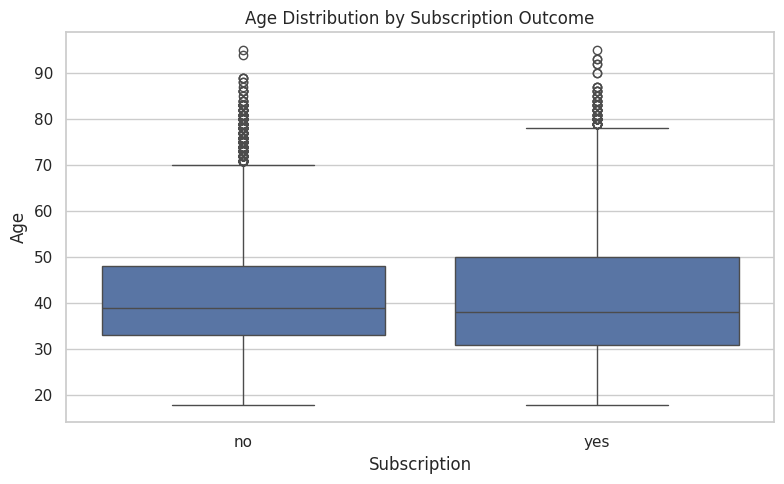

In [27]:
# 5.3 Age vs Subscription
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="y",
    y="age"
)

plt.title("Age Distribution by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

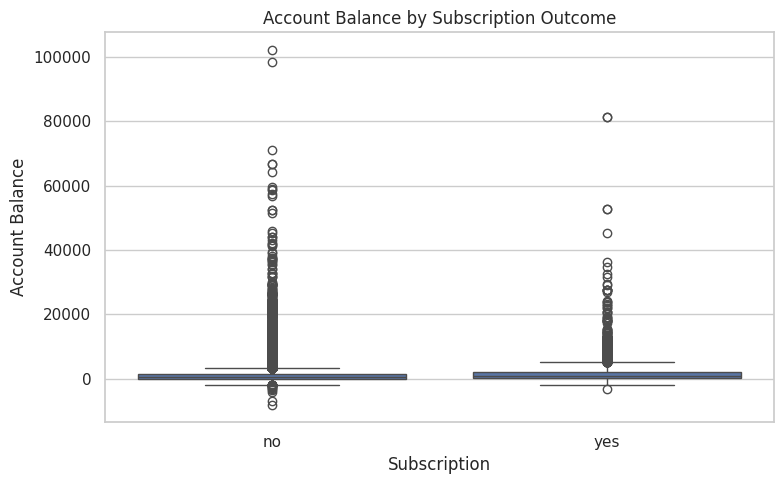

In [28]:
# 5.4 Balance vs Subscription
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="y",
    y="balance"
)

plt.title("Account Balance by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Account Balance")

plt.tight_layout()
plt.show()


Subscription rate by contact method:


y,no,yes
contact,,
cellular,85.081100,14.918900
telephone,86.579491,13.420509
unknown,95.929339,4.070661


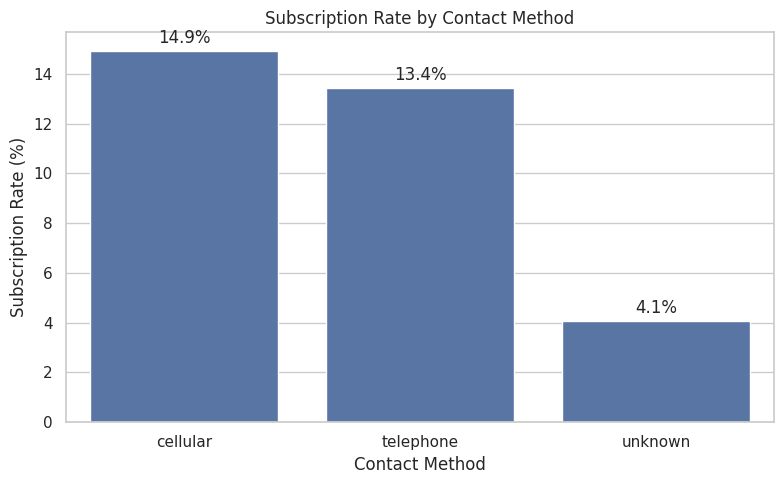

In [29]:
# 5.5 Contact Method vs Subscription
# ------------------------------------------------------------

contact_subscription = (
    pd.crosstab(
        df["contact"],
        df["y"],
        normalize="index"
    ) * 100
)

print("\nSubscription rate by contact method:")
display(contact_subscription)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contact_subscription.reset_index(),
    x="contact",
    y="yes"
)

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


Average campaign contacts by subscription:


,y,campaign
0,no,2.846350
1,yes,2.141047


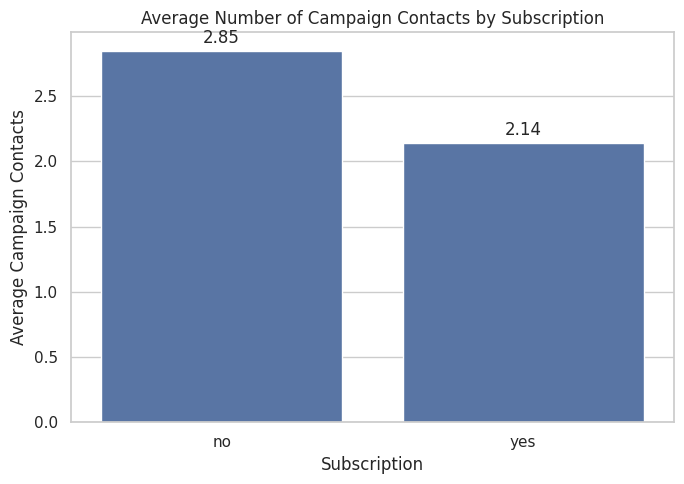

In [30]:
# 5.6 Campaign Contacts vs Subscription
# ------------------------------------------------------------

campaign_subscription = (
    df.groupby("y")["campaign"]
    .mean()
    .reset_index()
)

print("\nAverage campaign contacts by subscription:")
display(campaign_subscription)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=campaign_subscription,
    x="y",
    y="campaign"
)

plt.title("Average Number of Campaign Contacts by Subscription")
plt.xlabel("Subscription")
plt.ylabel("Average Campaign Contacts")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

# 6. MULTIVARIATE EXPLORATORY DATA ANALYSIS

MULTIVARIATE EXPLORATORY DATA ANALYSIS

Subscription rate by age group:


y,no,yes
age_group,,
18-25,76.047904,23.952096
26-35,87.996917,12.003083
36-45,90.610566,9.389434
46-55,90.647256,9.352744
56-65,85.876115,14.123885
66+,57.390146,42.609854


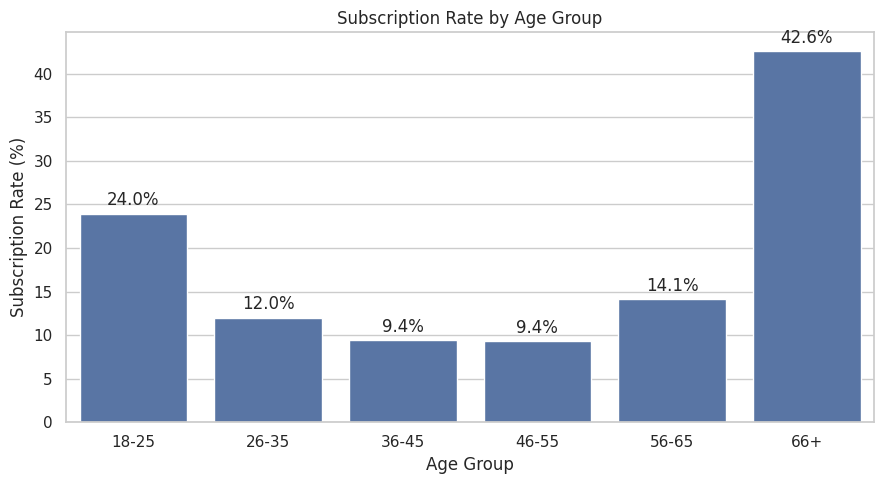

In [31]:
print("=" * 60)
print("MULTIVARIATE EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 6.1 Create Age Groups
# ------------------------------------------------------------

df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

age_subscription = (
    pd.crosstab(
        df["age_group"],
        df["y"],
        normalize="index"
    ) * 100
)

print("\nSubscription rate by age group:")
display(age_subscription)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=age_subscription.reset_index(),
    x="age_group",
    y="yes"
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


Subscription rate by job and education:


,job,education,subscription_rate
32,student,primary,36.363636
33,student,secondary,29.724409
22,retired,tertiary,27.595628
34,student,tertiary,26.457399
35,student,unknown,26.380368
23,retired,unknown,25.210084
20,retired,primary,22.389937
21,retired,secondary,21.036585
19,management,unknown,19.834711
42,unemployed,tertiary,19.377163


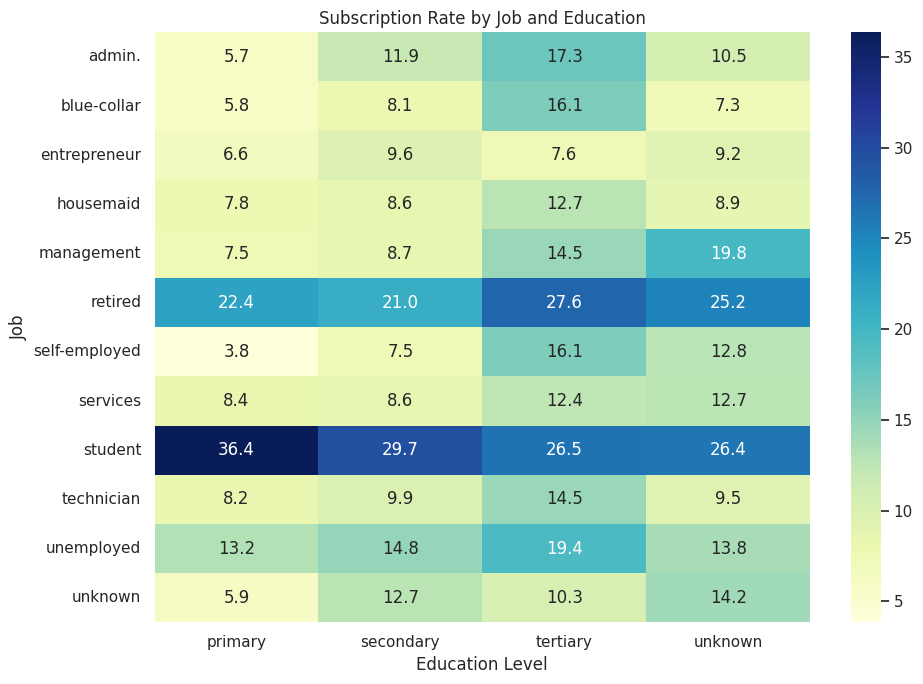

In [32]:
# 6.2 Job and Education vs Subscription
# ------------------------------------------------------------

job_education = (
    df.groupby(
        ["job", "education"],
        observed=True
    )["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

print("\nSubscription rate by job and education:")
display(
    job_education.sort_values(
        "subscription_rate",
        ascending=False
    ).head(15)
)

# Pivot table for heatmap
job_education_pivot = job_education.pivot(
    index="job",
    columns="education",
    values="subscription_rate"
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    job_education_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Subscription Rate by Job and Education")
plt.xlabel("Education Level")
plt.ylabel("Job")

plt.tight_layout()
plt.show()


Average campaign contacts by contact method and subscription:


,contact,y,campaign
0,cellular,no,2.797520
1,cellular,yes,2.077592
2,telephone,no,3.556439
3,telephone,yes,2.397436
4,unknown,no,2.800721
5,unknown,yes,2.475472


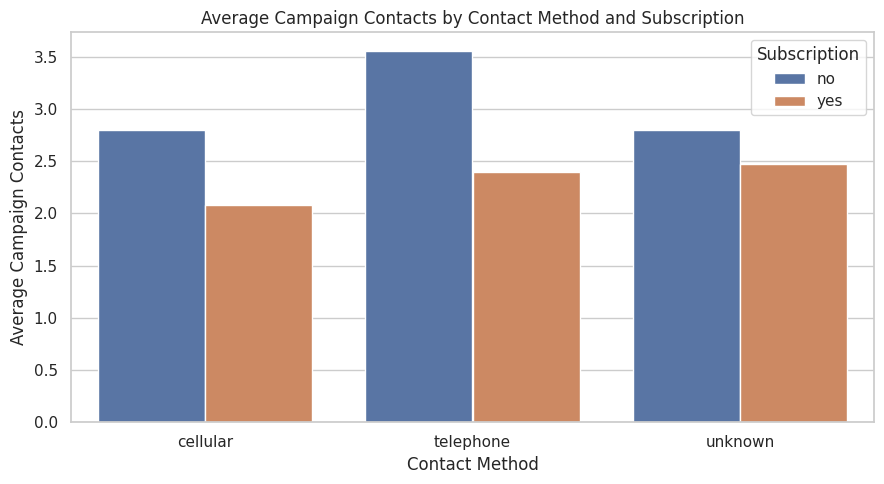

In [33]:
# 6.3 Contact Method and Campaign Contacts
# ------------------------------------------------------------

contact_campaign = (
    df.groupby(["contact", "y"])["campaign"]
    .mean()
    .reset_index()
)

print("\nAverage campaign contacts by contact method and subscription:")
display(contact_campaign)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contact_campaign,
    x="contact",
    y="campaign",
    hue="y"
)

plt.title("Average Campaign Contacts by Contact Method and Subscription")
plt.xlabel("Contact Method")
plt.ylabel("Average Campaign Contacts")
plt.legend(title="Subscription")

plt.tight_layout()
plt.show()


Subscription rate by previous campaign outcome:


y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


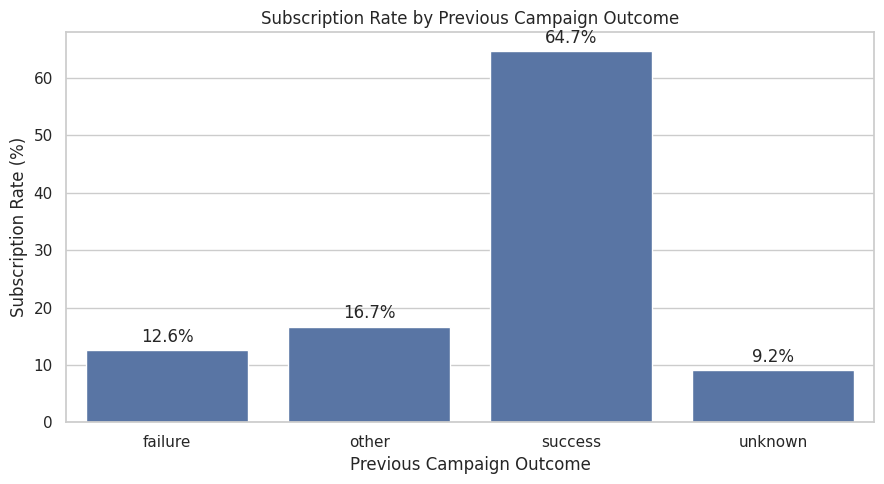

In [34]:
# 6.4 Previous Campaign Outcome vs Subscription
# ------------------------------------------------------------

poutcome_subscription = (
    pd.crosstab(
        df["poutcome"],
        df["y"],
        normalize="index"
    ) * 100
)

print("\nSubscription rate by previous campaign outcome:")
display(poutcome_subscription)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=poutcome_subscription.reset_index(),
    x="poutcome",
    y="yes"
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [35]:
# 6.5 Numerical Feature Relationships
# ------------------------------------------------------------

numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

print("\nCorrelation matrix:")
display(
    df[numeric_features].corr().round(2)
)


Correlation matrix:


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


# 7. CORRELATION ANALYSIS

In [36]:
print("CORRELATION ANALYSIS")
print("=" * 60)

numeric_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]


CORRELATION ANALYSIS


In [37]:
# 7.1 Correlation Matrix
# ------------------------------------------------------------

correlation_matrix = df[numeric_features].corr()

print("\nCorrelation Matrix:")
display(correlation_matrix.round(2))


Correlation Matrix:


,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


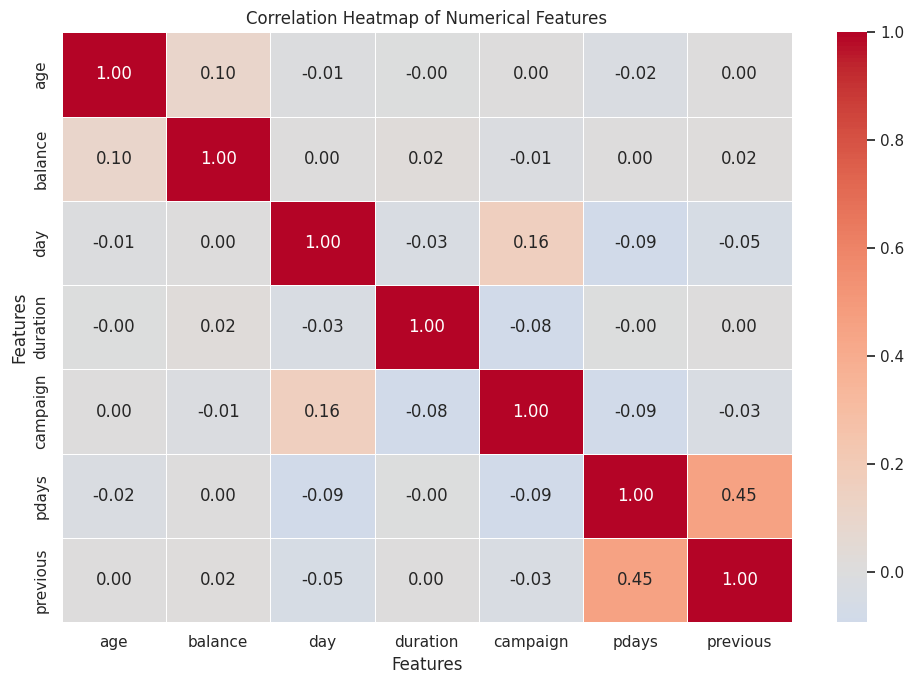

In [38]:
# 7.2 Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

Correlation of numerical features with subscription:


,subscription_binary
duration,0.395
pdays,0.104
previous,0.093
balance,0.053
age,0.025
day,-0.028
campaign,-0.073


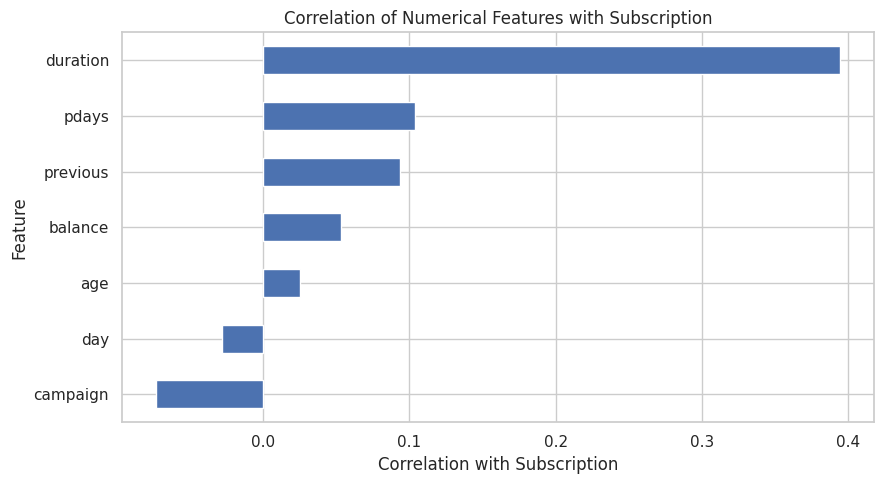

In [39]:
# 7.3 Numerical Features vs Subscription
# ============================================================

# Create binary representation of the target
df["subscription_binary"] = df["y"].map({
    "no": 0,
    "yes": 1
})

target_correlation = (
    df[numeric_features + ["subscription_binary"]]
    .corr()["subscription_binary"]
    .drop("subscription_binary")
    .sort_values(ascending=False)
)

print("Correlation of numerical features with subscription:")
display(target_correlation.round(3))

plt.figure(figsize=(9, 5))

target_correlation.sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Subscription")
plt.xlabel("Correlation with Subscription")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [40]:
# 7.4 Strongest Numerical Correlations
# ============================================================

corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Strongest numerical feature relationships:")
display(corr_pairs.head(10).round(3))

Strongest numerical feature relationships:


,,0
pdays,previous,0.455
day,campaign,0.162
age,balance,0.098
day,pdays,-0.093
campaign,pdays,-0.089
duration,campaign,-0.085
day,previous,-0.052
campaign,previous,-0.033
day,duration,-0.030
age,pdays,-0.024


# 8. DATA TRANSFORMATIONS AND AGGREGATIONS

DATA TRANSFORMATIONS AND AGGREGATIONS

Subscription rate by month:


y,no,yes
month,,
jan,89.878831,10.121169
feb,83.352208,16.647792
mar,48.008386,51.991614
apr,80.320600,19.679400
may,93.280546,6.719454
jun,89.777195,10.222805
jul,90.906454,9.093546
aug,88.986714,11.013286
sep,53.540587,46.459413


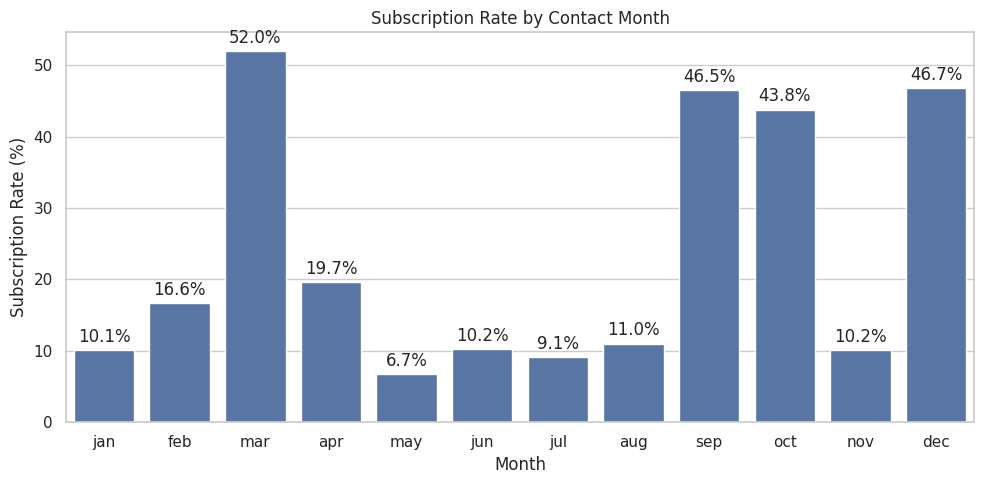

In [41]:
print("=" * 60)
print("DATA TRANSFORMATIONS AND AGGREGATIONS")
print("=" * 60)

# ------------------------------------------------------------
# 8.1 Subscription Rate by Month
# ------------------------------------------------------------

month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

month_subscription = (
    pd.crosstab(
        df["month"],
        df["y"],
        normalize="index"
    ) * 100
)

month_subscription = month_subscription.reindex(month_order)

print("\nSubscription rate by month:")
display(month_subscription)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=month_subscription.reset_index(),
    x="month",
    y="yes",
    order=month_order
)

plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


Subscription rate by campaign intensity:


y,no,yes
campaign_group,,
1,85.402417,14.597583
2,88.796481,11.203519
3,88.806376,11.193624
4-5,91.373439,8.626561
6-10,93.478949,6.521051
11+,96.070234,3.929766


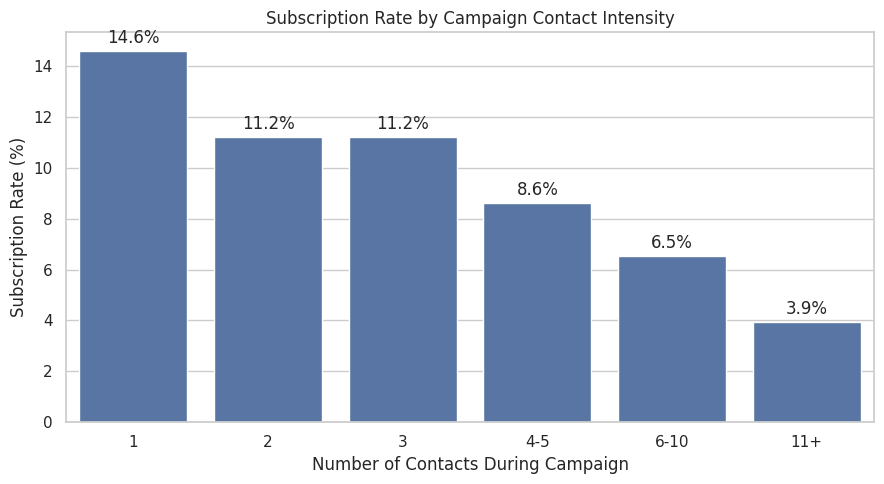

In [42]:
# 8.2 Campaign Intensity Groups
# ------------------------------------------------------------

df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=[
        "1",
        "2",
        "3",
        "4-5",
        "6-10",
        "11+"
    ]
)

campaign_subscription = (
    pd.crosstab(
        df["campaign_group"],
        df["y"],
        normalize="index"
    ) * 100
)

print("\nSubscription rate by campaign intensity:")
display(campaign_subscription)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=campaign_subscription.reset_index(),
    x="campaign_group",
    y="yes"
)

plt.title("Subscription Rate by Campaign Contact Intensity")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Subscription Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()


Call duration summary by subscription:


,mean,median,min,max
y,,,,
no,221.18,164.0,0,4918
yes,537.29,426.0,8,3881


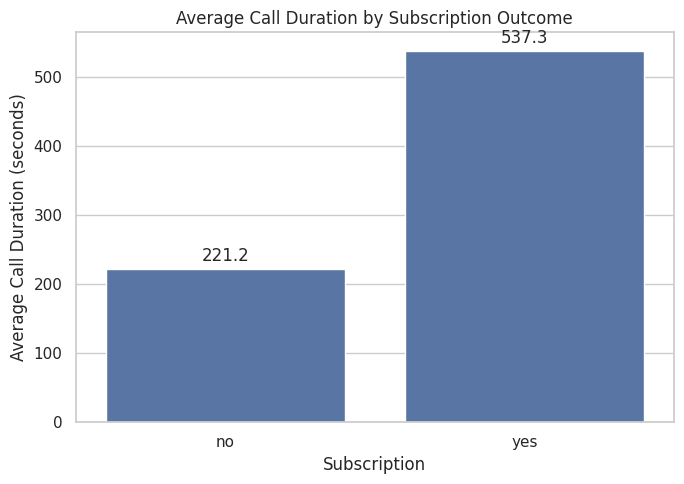

In [43]:
# ------------------------------------------------------------
# 8.3 Average Call Duration by Subscription
# ------------------------------------------------------------

duration_summary = (
    df.groupby("y")["duration"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

print("\nCall duration summary by subscription:")
display(duration_summary)

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=duration_summary.reset_index(),
    x="y",
    y="mean"
)

plt.title("Average Call Duration by Subscription Outcome")
plt.xlabel("Subscription")
plt.ylabel("Average Call Duration (seconds)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.tight_layout()
plt.show()


Subscription rate by age group and previous campaign outcome:


,age_group,poutcome,subscription_rate
2,18-25,success,77.631579
22,66+,success,72.131148
18,56-65,success,70.680628
14,46-55,success,65.200000
10,36-45,success,62.702703
6,26-35,success,59.960159
21,66+,other,40.000000
23,66+,unknown,37.473684
20,66+,failure,32.692308
1,18-25,other,31.250000


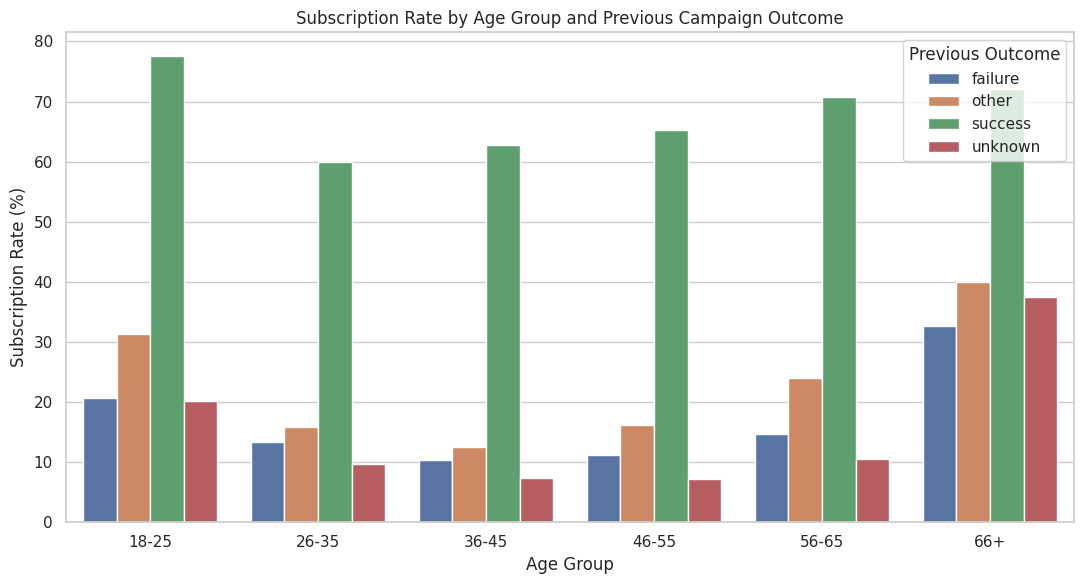

In [44]:
# ------------------------------------------------------------
# 8.4 Previous Campaign Outcome + Age Group
# ------------------------------------------------------------

age_poutcome = (
    df.groupby(
        ["age_group", "poutcome"],
        observed=True
    )["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="subscription_rate")
)

print("\nSubscription rate by age group and previous campaign outcome:")

display(
    age_poutcome.sort_values(
        "subscription_rate",
        ascending=False
    ).head(20)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=age_poutcome,
    x="age_group",
    y="subscription_rate",
    hue="poutcome"
)

plt.title(
    "Subscription Rate by Age Group and Previous Campaign Outcome"
)

plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.legend(title="Previous Outcome")

plt.tight_layout()
plt.show()

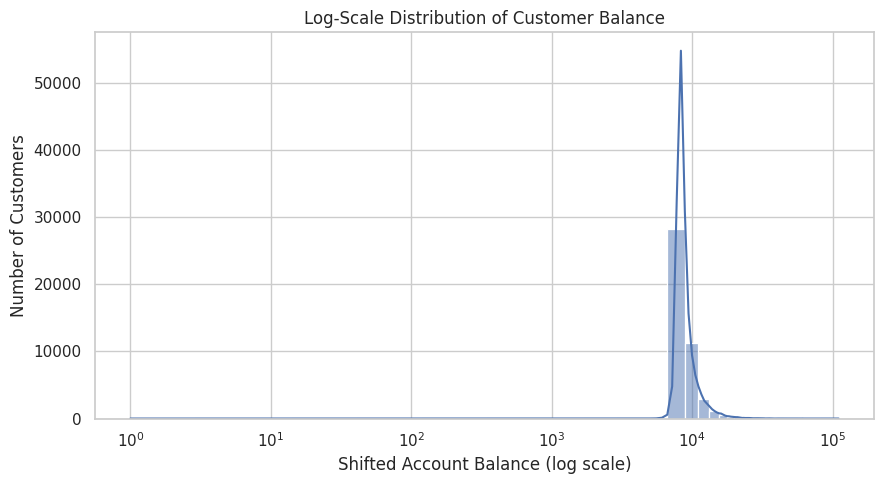

In [45]:
# ------------------------------------------------------------
# 8.5 Log-Scale Balance Visualization
# ------------------------------------------------------------

# Shift balance so that negative values can also be displayed
balance_shift = abs(df["balance"].min()) + 1

df["balance_shifted"] = df["balance"] + balance_shift

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="balance_shifted",
    bins=50,
    kde=True
)

plt.xscale("log")

plt.title("Log-Scale Distribution of Customer Balance")
plt.xlabel("Shifted Account Balance (log scale)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [46]:
# ------------------------------------------------------------
# 8.6 EDA Summary Table
# ------------------------------------------------------------

summary_table = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Subscription Rate",
        "Average Age",
        "Average Balance",
        "Average Call Duration",
        "Average Campaign Contacts",
        "Customers with Previous Contact"
    ],
    "Value": [
        len(df),
        f"{(df['y'] == 'yes').mean() * 100:.2f}%",
        f"{df['age'].mean():.2f}",
        f"{df['balance'].mean():.2f}",
        f"{df['duration'].mean():.2f} sec",
        f"{df['campaign'].mean():.2f}",
        f"{(df['previous'] > 0).sum()}"
    ]
})

print("\nOverall EDA Summary:")
display(summary_table)


Overall EDA Summary:


,Metric,Value
0,Total Customers,45211
1,Subscription Rate,11.70%
2,Average Age,40.94
3,Average Balance,1362.27
4,Average Call Duration,258.16 sec
5,Average Campaign Contacts,2.76
6,Customers with Previous Contact,8257


# 9. FINAL INSIGHTS AND CRITICAL INTERPRETATION

In [47]:
print("=" * 60)
print("FINAL EDA INSIGHTS")
print("=" * 60)

# ------------------------------------------------------------
# 9.1 Overall subscription rate
# ------------------------------------------------------------

overall_rate = (df["y"] == "yes").mean() * 100

print(f"\nOverall subscription rate: {overall_rate:.2f}%")

FINAL EDA INSIGHTS

Overall subscription rate: 11.70%


In [54]:
# 9.2 Highest and lowest subscription rate by job
# ------------------------------------------------------------

job_rates = (
    df.groupby("job")["subscription_binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nHighest subscription-rate jobs:")
display(job_rates.head(5).round(2))

print("\nLowest subscription-rate jobs:")
display(job_rates.tail(5).round(2))


Highest subscription-rate jobs:


,subscription_binary
job,
student,28.68
retired,22.79
unemployed,15.50
management,13.76
admin.,12.20



Lowest subscription-rate jobs:


,subscription_binary
job,
technician,11.06
services,8.88
housemaid,8.79
entrepreneur,8.27
blue-collar,7.27


In [53]:
# 9.3 Highest and lowest subscription rate by month
# ------------------------------------------------------------

month_rates = (
    df.groupby("month")["subscription_binary"]
    .mean()
    .mul(100)
    .reindex(month_order)
)

print("\nSubscription rate by month:")
display(month_rates.round(2))

print("\nBest-performing months:")
display(month_rates.sort_values(ascending=False).head(5).round(2))

print("\nLowest-performing months:")
display(month_rates.sort_values().head(5).round(2))


Subscription rate by month:


,subscription_binary
month,
jan,10.12
feb,16.65
mar,51.99
apr,19.68
may,6.72
jun,10.22
jul,9.09
aug,11.01
sep,46.46



Best-performing months:


,subscription_binary
month,
mar,51.99
dec,46.73
sep,46.46
oct,43.77
apr,19.68



Lowest-performing months:


,subscription_binary
month,
may,6.72
jul,9.09
jan,10.12
nov,10.15
jun,10.22


In [52]:
# 9.4 Highest and lowest subscription rate by age group
# ------------------------------------------------------------

age_rates = (
    df.groupby("age_group", observed=True)["subscription_binary"]
    .mean()
    .mul(100)
)

print("\nSubscription rate by age group:")
display(age_rates.round(2))

print("\nHighest-performing age groups:")
display(age_rates.sort_values(ascending=False).head(3).round(2))


Subscription rate by age group:


,subscription_binary
age_group,
18-25,23.95
26-35,12.00
36-45,9.39
46-55,9.35
56-65,14.12
66+,42.61



Highest-performing age groups:


,subscription_binary
age_group,
66+,42.61
18-25,23.95
56-65,14.12


In [51]:
# 9.5 Campaign intensity analysis
# ------------------------------------------------------------

campaign_rates = (
    df.groupby("campaign_group", observed=True)["subscription_binary"]
    .mean()
    .mul(100)
)

print("\nSubscription rate by campaign intensity:")
display(campaign_rates.round(2))


Subscription rate by campaign intensity:


,subscription_binary
campaign_group,
1,14.60
2,11.20
3,11.19
4-5,8.63
6-10,6.52
11+,3.93


In [50]:
# 9.6 Previous campaign outcome
# ------------------------------------------------------------

previous_rates = (
    df.groupby("poutcome")["subscription_binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nSubscription rate by previous campaign outcome:")
display(previous_rates.round(2))


Subscription rate by previous campaign outcome:


,subscription_binary
poutcome,
success,64.73
other,16.68
failure,12.61
unknown,9.16


In [49]:
# 9.7 Duration comparison
# ------------------------------------------------------------

duration_by_outcome = (
    df.groupby("y")["duration"]
    .agg(["mean", "median"])
    .round(2)
)

print("\nCall duration by subscription outcome:")
display(duration_by_outcome)


Call duration by subscription outcome:


,mean,median
y,,
no,221.18,164.0
yes,537.29,426.0


In [48]:
# 9.8 Contact method
# ------------------------------------------------------------

contact_rates = (
    df.groupby("contact")["subscription_binary"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\nSubscription rate by contact method:")
display(contact_rates.round(2))


print("\n" + "=" * 60)
print("FINAL INSIGHT EXTRACTION COMPLETED")
print("=" * 60)


Subscription rate by contact method:


,subscription_binary
contact,
cellular,14.92
telephone,13.42
unknown,4.07



FINAL INSIGHT EXTRACTION COMPLETED
